# Análisis del Índice de pobreza multidimensional

## Librerías y funciones

In [31]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv(r"C:\Users\camil\Documents\Estudio\Seminario\Bases de datos\IPM_2018_2024_CLEAN_CARIBE.csv",sep = ';')

In [33]:
import matplotlib.pyplot as plt

def plot_privacion(df, variable, titulo):
    # Conteo
    conteo = df[variable].value_counts().sort_index()
    conteo.index = ["No privación", "Privación"]    

    # Proporciones
    proporcion = conteo / conteo.sum()

    colors = ["#4CAF50", "#E74C3C"]

    fig, ax = plt.subplots(figsize=(7,5))

    bars = ax.bar(conteo.index, conteo.values, color=colors, edgecolor="black")

    ax.set_title(titulo, fontsize=14, pad=15)
    ax.set_xlabel("Estado")
    ax.set_ylabel("Frecuencia")

    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Etiquetas
    for i, bar in enumerate(bars):
        height = bar.get_height()

        # Frecuencia
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=10
        )

        # Proporción
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height/2,
            f"{proporcion.iloc[i]:.1%}",
            ha="center",
            va="center",
            fontsize=10,
            color="black",
            bbox=dict(
                facecolor="lightgray",
                edgecolor="none",
                alpha=0.8,
                boxstyle="round,pad=0.3"
            )
        )

    plt.tight_layout()
    plt.show()

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_evolucion_y_departamento(df, variable, titulo):
    
    fig, axes = plt.subplots(1, 2, figsize=(18,6))
    
    # ─────────────────────────────
    # 1. BARRAS (IZQUIERDA)
    # ─────────────────────────────
    tabla = pd.crosstab(
        df["departamento_nombre"],
        df[variable],
        normalize="index"
    )

    tabla.columns = ["No privación", "Privación"]
    tabla = tabla.sort_values("Privación", ascending=True)

    ax1 = axes[0]

    colors = ["#4CAF50", "#E74C3C"]

    tabla.plot(
        kind="barh",
        stacked=True,
        ax=ax1,
        color=colors,
        edgecolor="black"
    )

    ax1.set_title(f"{titulo} por departamento", fontsize=13, pad=10)
    ax1.set_xlabel("Proporción")
    ax1.set_ylabel("Departamento")

    ax1.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax1.set_axisbelow(True)

    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # Etiquetas
    for container in ax1.containers:
        labels = [f"{v:.1%}" for v in container.datavalues]

        ax1.bar_label(
            container,
            labels=labels,
            label_type="center",
            fontsize=8,
            bbox=dict(
                facecolor="lightgray",
                edgecolor="none",
                alpha=0.8,
                boxstyle="round,pad=0.2"
            )
        )

    # ─────────────────────────────
    # 2. EVOLUCIÓN (DERECHA)
    # ─────────────────────────────
    evolucion = df.groupby(
        ["año", "departamento_nombre"]
    )[variable].mean().reset_index()

    ax2 = axes[1]

    for dep in evolucion["departamento_nombre"].unique():
        subset = evolucion[evolucion["departamento_nombre"] == dep]
        
        ax2.plot(
            subset["año"],
            subset[variable],
            marker="o",
            linewidth=2,
            label=dep  # 🔥 clave para la leyenda
        )

    ax2.set_title(f"Evolución de {titulo}", fontsize=13, pad=10)
    ax2.set_xlabel("Año")
    ax2.set_ylabel("Proporción de privación")

    ax2.axvline(
        x=2020,
        linestyle="dotted",
        linewidth=2,
        color="red",
        alpha=0.7
    )

    ax2.grid(True, linestyle="--", alpha=0.4)

    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    # ✅ LEYENDA CORREGIDA
    ax2.legend(
        title="Departamento",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

In [35]:
# Revisar columnas tipo object
df["fex_c"] = pd.to_numeric(
    df["fex_c"]
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip(),
    errors="coerce"
)

df["fexp"] = pd.to_numeric(
    df["fexp"]
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip(),
    errors="coerce"
)

df["ipm"] = pd.to_numeric(
    df["ipm"]
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip(),
    errors="coerce"
)

## Análisis por dimensión

## Educación

- Documentación importante: 
    - https://www.atlantico.gov.co/images/stories/adjuntos/educacion/orientac_eval_prom_estudiantes003.pdf.
    - https://redclade.org/wp-content/uploads/Documento-de-Trabajo_educacion-y-pandemia.pdf

### Alfabetismo

La variable alfabetismo del DANE indica una privación a nivel del hogar, tomando valor 1 (privación) si al menos un miembro del hogar mayor a 15 años no sabe leer ni escribir, y 0 (No privación) en caso contrario.


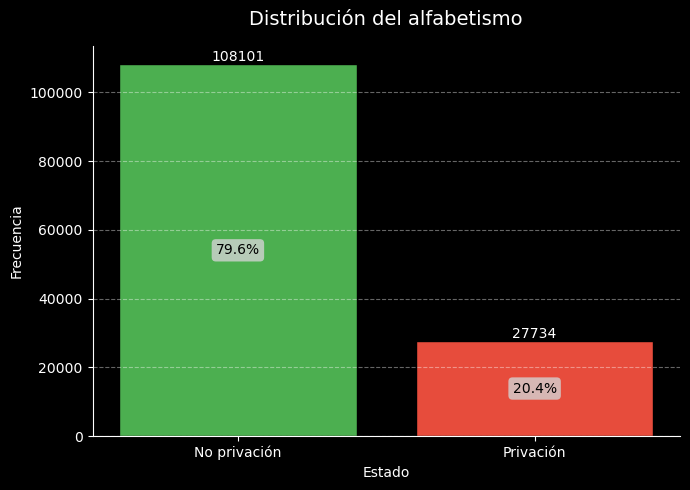

In [36]:
plot_privacion(df, "alfabetismo", "Distribución del alfabetismo")

- Prevalencia: El 20.4% de la población analizada presenta privación (no alfabetización), lo que afecta a 27,734 personas.

- Estado predominante: El 79.6% cuenta con "No privación", estableciendo una relación de 4 a 1 frente a quienes sí tienen la carencia.

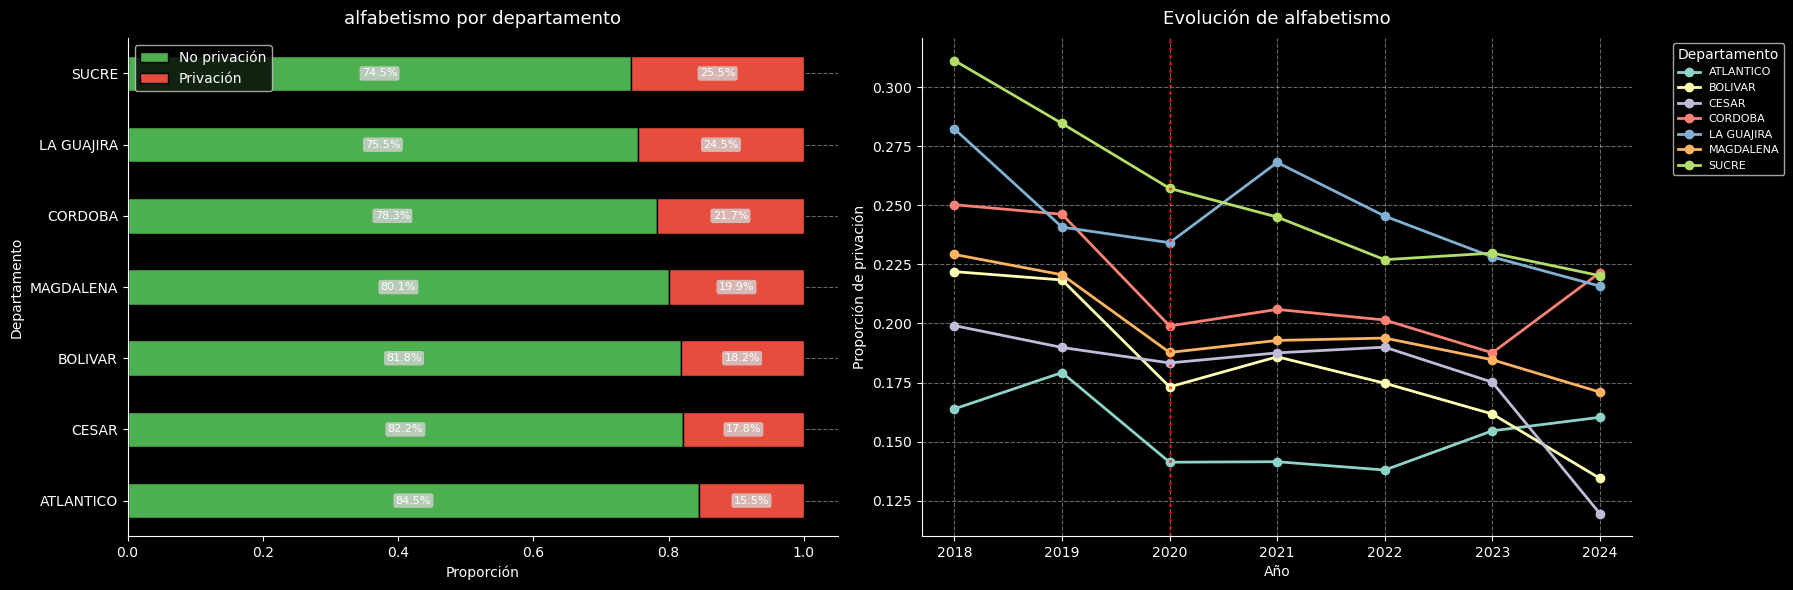

In [37]:
plot_evolucion_y_departamento(df, "alfabetismo", "alfabetismo")

- La privación en alfabetismo afecta al 20.4% de la población analizada. En contraste, el logro educativo presenta un panorama más crítico con una privación del 56.0%.

- Pandemia (2020): La caída en las curvas de privación durante 2020 (marcada con la línea roja) coincide con la emisión de la Circular No. 003-2020. Este documento instruyó a los colegios a:

    - Implementar una flexibilización curricular priorizando el bienestar del estudiante.

    - Adoptar una evaluación formativa y no sancionatoria.

    - No reprobar a los estudiantes por inasistencia debido a la emergencia sanitaria.

### Logro educativo

indica una privación a nivel del hogar, tomando valor 1 (privación) si el promedio de años de educación de los miembros del hogar mayores de 15 años es inferior al umbral establecido: que se haya aprobado como mínimo el 9no grado, y 0 (No privación) en caso contrario.

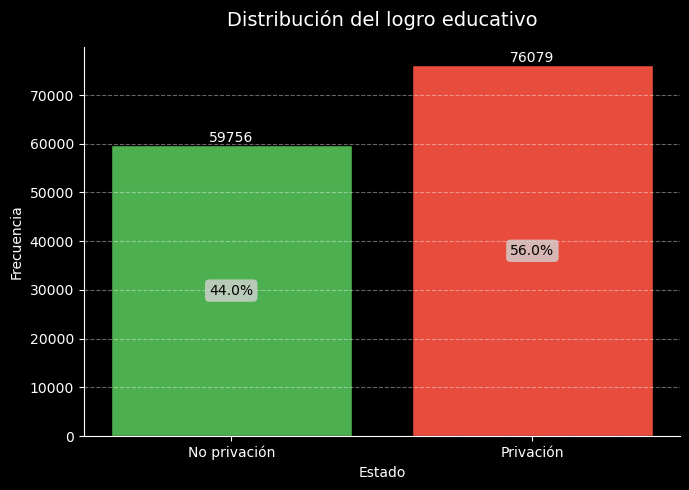

In [38]:
plot_privacion(df, "logro_educativo", "Distribución del logro educativo")

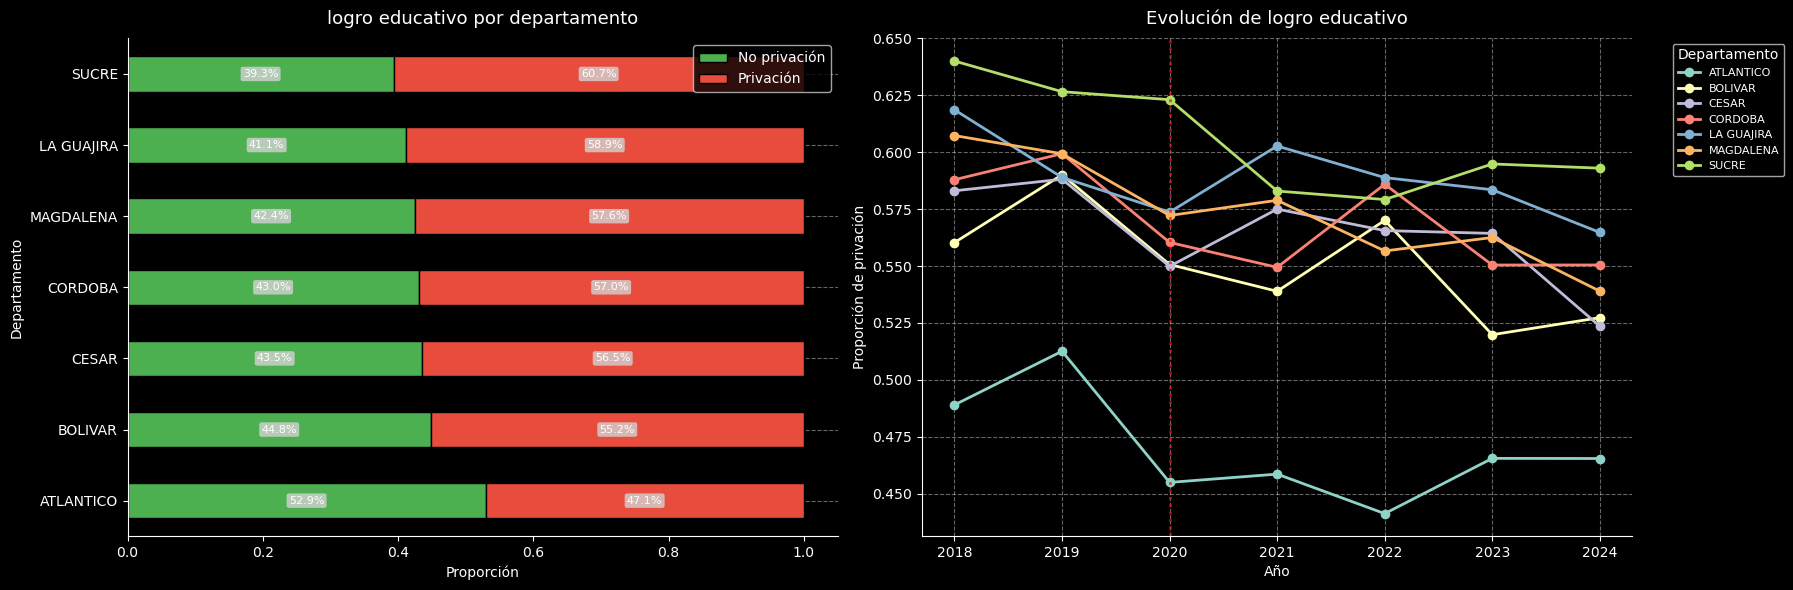

In [39]:
plot_evolucion_y_departamento(df, "logro_educativo", "logro educativo")

- Estado de la Privación: El alfabetismo presenta una privación del 20.4%, mientras que el logro educativo es significativamente más crítico, afectando al 56.0% de la población analizada.

- Contexto de Pandemia (2020): Se observa una caída técnica en la privación durante 2020. Esto coincide con la Circular No. 003-2020 del Atlántico, que estableció:

    - Flexibilización Curricular: Priorización de aprendizajes esenciales y bienestar del estudiante sobre contenidos rígidos.

    - Evaluación No Sancionatoria: Un enfoque formativo centrado en avances y aciertos, evitando el castigo ante la adversidad.

    - Protección de la Trayectoria: La recomendación explícita de no usar la inasistencia como factor de reprobación, lo que facilitó la promoción escolar estadística

## Niñez y juventud

### Inasistencia escolar

Indica una privación a nivel del hogar, tomando valor 1 (privación) si al menos un niño de 6 a 16 años no asiste a una institución educativa o, en caso de educación virtual, no cuenta con conexión a internet, dispositivos o comunicación semanal con el docente, y 0 (No privación) en caso contrario.

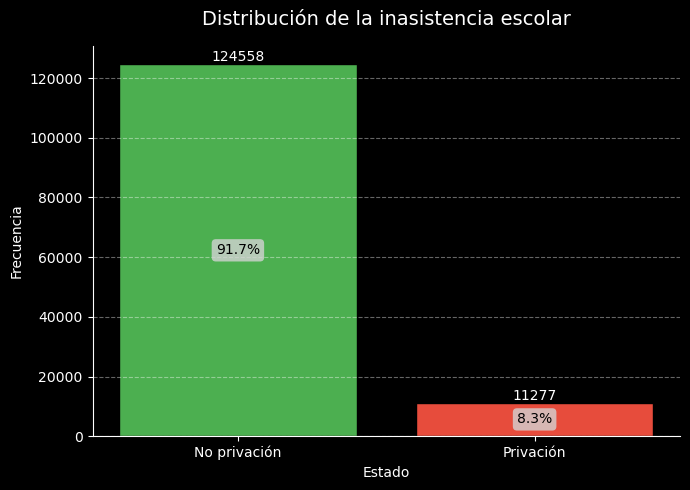

In [40]:
plot_privacion(df, "inasistencia_escolar", "Distribución de la inasistencia escolar")

- Nivel de Privación: Solo el 8.3% de los hogares (11,277 casos) presenta privación por inasistencia escolar.

- Estado Predominante: La gran mayoría de la muestra, un 91.7% (124,558 hogares), se encuentra en situación de "No privación"

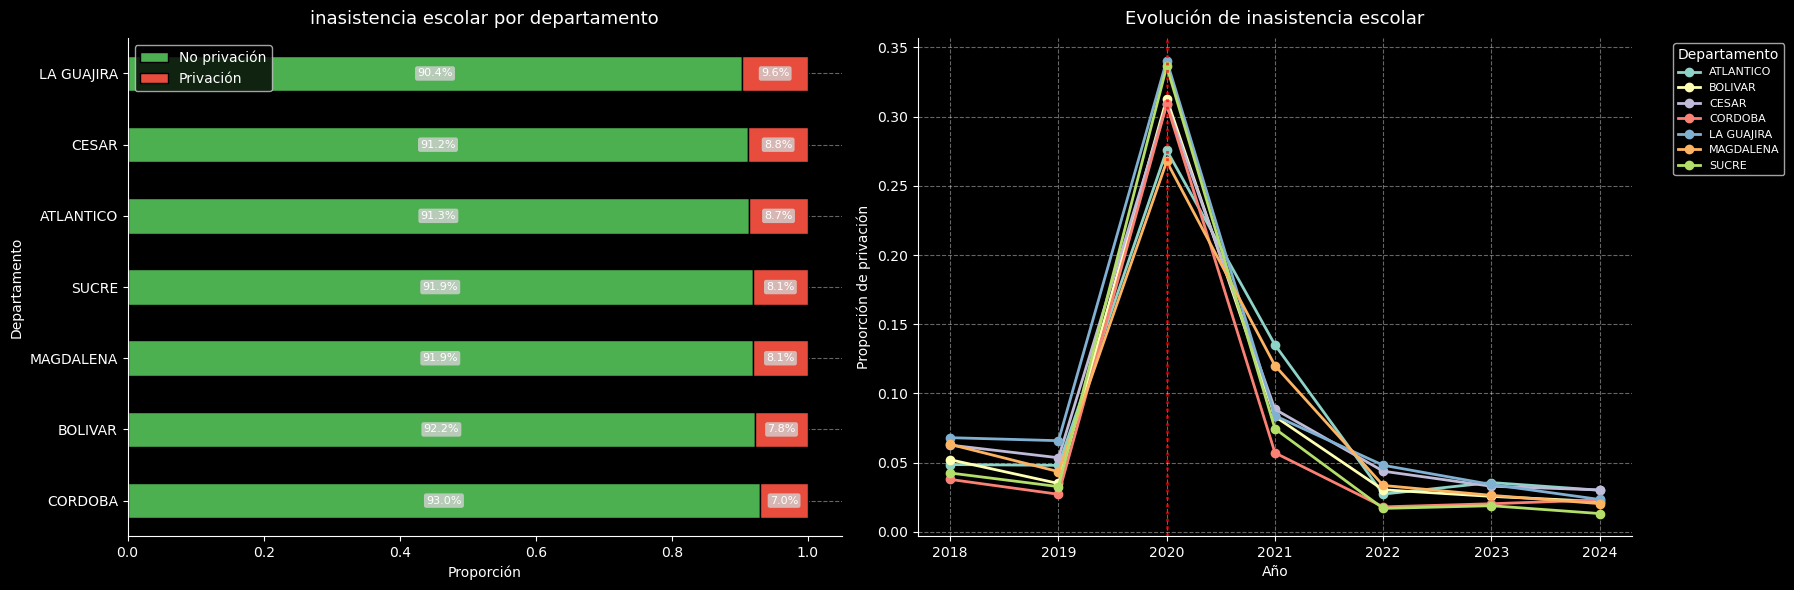

In [41]:
plot_evolucion_y_departamento(df, "inasistencia_escolar", "inasistencia escolar")

- Pico Atípico en 2020: Se observa un aumento drástico y generalizado en la proporción de privación en todos los departamentos durante el año 2020, alcanzando niveles cercanos al 35% en lugares como La Guajira y Sucre, esto lo correspondemos a la pandemia.

- Ranking Departamental: La Guajira presenta la mayor proporción acumulada de privación (9.6%), mientras que Córdoba registra el mejor desempeño con la menor tasa de inasistencia (7.0%).

- Efecto de la Política Educativa: La rápida caída de la privación a partir de 2021 se alinea con las directrices de la Circular No. 003-2020, que recomendó explícitamente no incluir la inasistencia como factor para la reprobación del año escolar y priorizar la flexibilidad para mantener el vínculo de los estudiantes con el sistema.

- Normalización Post-Pandemia: Para el año 2024, todos los departamentos de la región Caribe han estabilizado sus niveles de inasistencia por debajo del 5%, retomando o mejorando sus tendencias históricas previas a la crisis sanitaria.

## Salud

### Aseguramiento salud

Indica una privación a nivel del hogar, tomando valor 1 (privación) si al menos un miembro mayor de 5 años no está asegurado en salud, y 0 (No privación) en caso contrario.

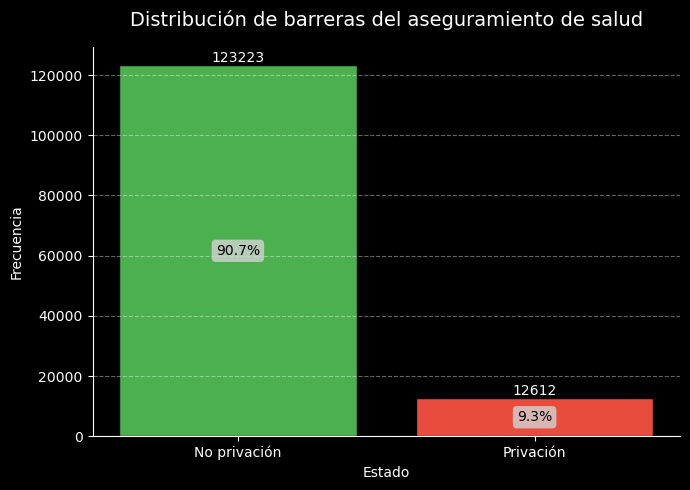

In [42]:
plot_privacion(df, "aseguramiento_salud", "Distribución de barreras del aseguramiento de salud")

- Nivel de Privación en Salud: El 9.3% de los hogares (12,612 casos) presenta privación por falta de aseguramiento en salud. Esto indica que en estos hogares hay al menos un miembro mayor de 5 años que no está afiliado al sistema de salud.

- Estado Predominante: La gran mayoría, el 90.7% (123,223 hogares), cuenta con aseguramiento, lo que representa una de las variables con menor privación en comparación con los indicadores educativos.

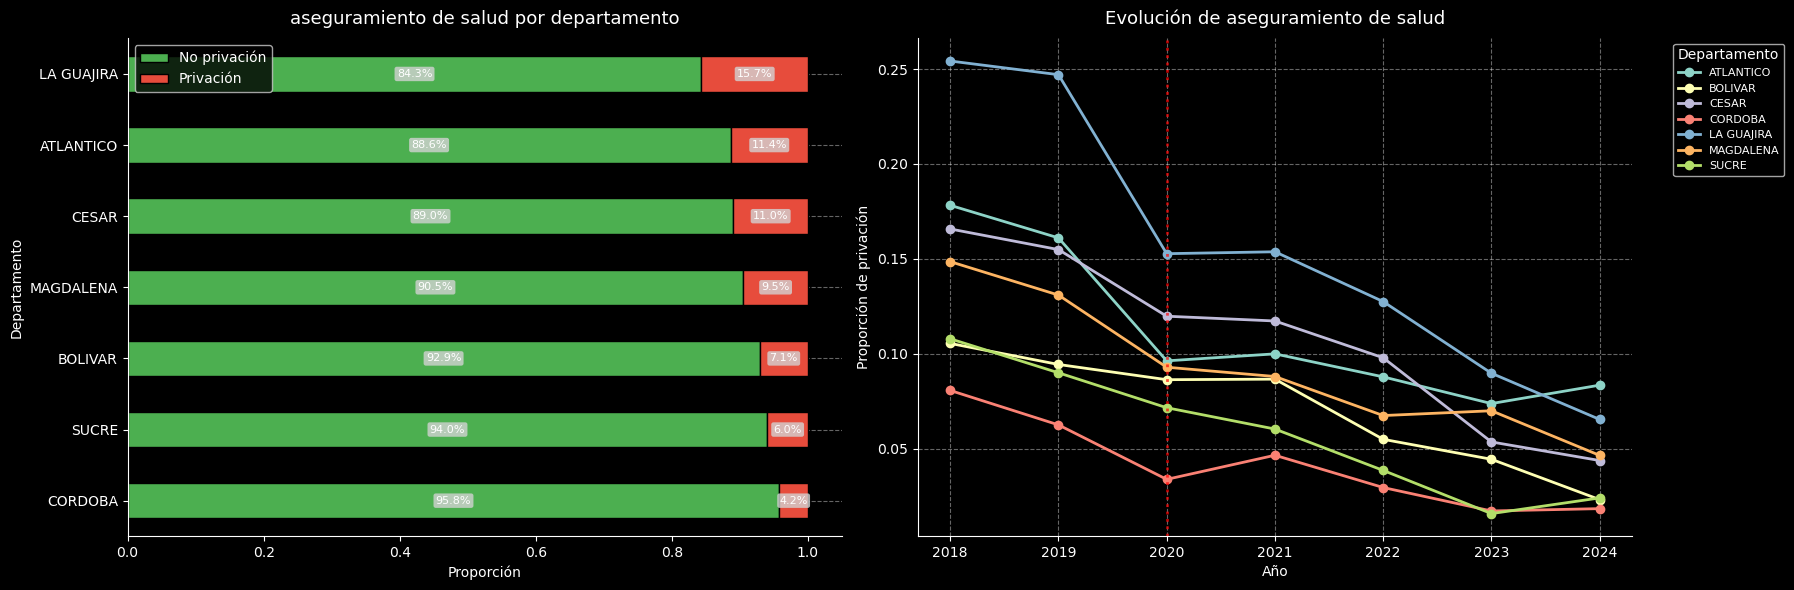

In [43]:
plot_evolucion_y_departamento(df, "aseguramiento_salud", "aseguramiento de salud")

- Desempeño en Salud: El 9.3% de la muestra total presenta privación en aseguramiento. A nivel departamental, La Guajira tiene la mayor privación (15.7%), mientras que Córdoba lidera con la mayor cobertura (solo 4.2% de privación).
- Se observa una reducción sostenida de la privación en salud en todos los departamentos desde 2018. El año 2020 (línea roja) muestra una caída notable en la falta de aseguramiento, lo que sugiere un fortalecimiento de la afiliación durante la emergencia sanitaria para garantizar el acceso a servicios básicos.

### Barreras de acceso a la salud

Indica una privación a nivel del hogar, tomando valor 1 (privación) si al menos un miembro que presentó enfermedad, accidente, problema odontológico u otra condición en los últimos 30 días no acudió a un profesional de salud o institución, y 0 (No privación) en caso contrario.

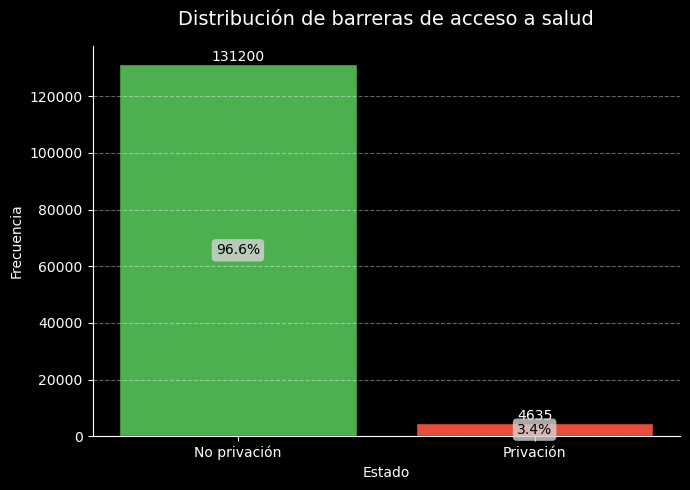

In [44]:
plot_privacion(df, "barreras_acceso_salud", "Distribución de barreras de acceso a salud")

- Baja Privación: Es uno de los indicadores con mejor desempeño, con solo un 3.4% de los hogares (4,635 casos) en situación de privación.

- Estado Predominante: El 96.6% de los hogares analizados (131,200 casos) no presenta barreras de acceso cuando surge una necesidad de salud.

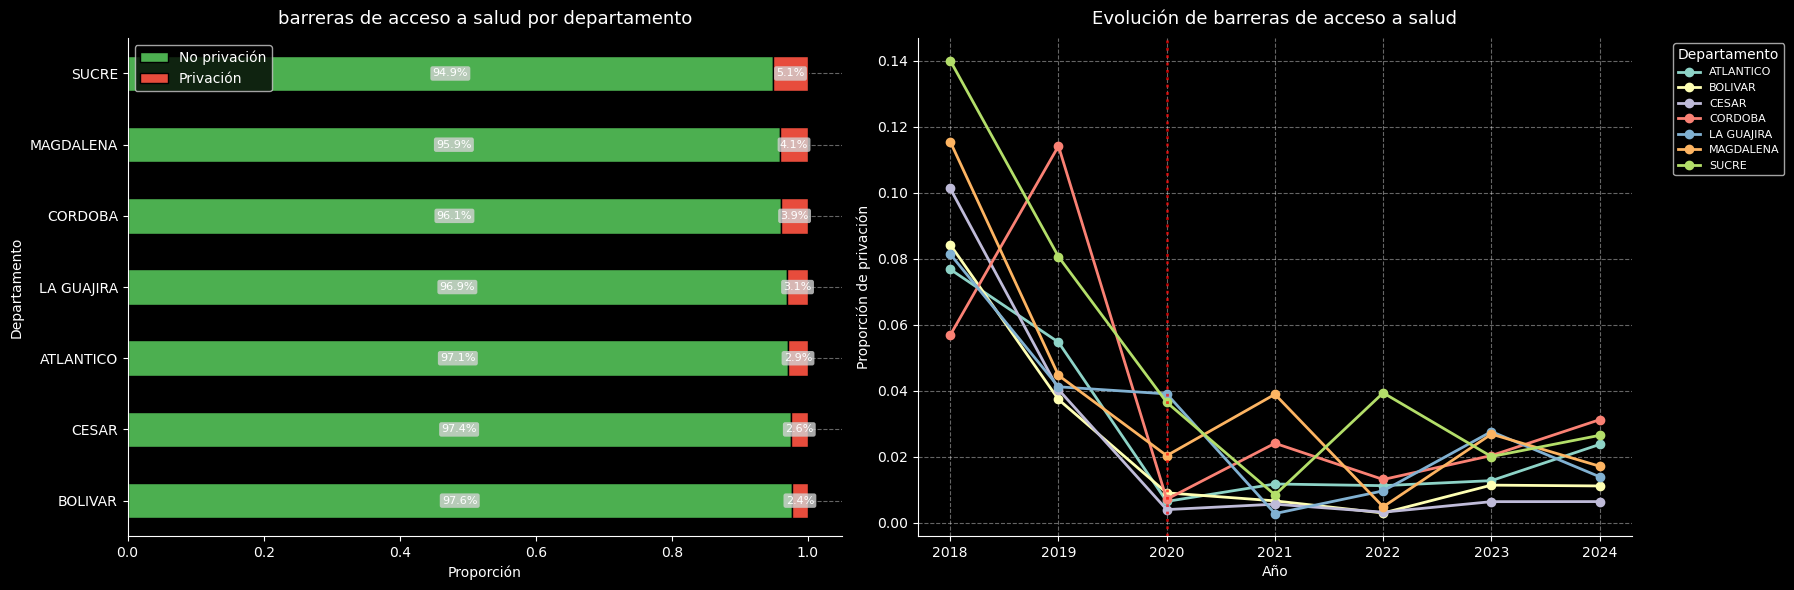

In [45]:
plot_evolucion_y_departamento(df, "barreras_acceso_salud", "barreras de acceso a salud")

- Eficacia Regional: El acceso a salud es uno de los indicadores más sólidos de la región Caribe, con una tasa de "No privación" del 96.6%.

- Líderes en Acceso: Bolívar (2.4%), Cesar (2.6%) y Atlántico (2.9%) registran las menores barreras de acceso, demostrando una infraestructura o procesos de atención más eficientes frente a sus pares.

- Impacto Positivo de la Pandemia (2020): Se observa una caída drástica en las barreras de acceso en el año 2020 para casi todos los departamentos.

## Empleo

### Empleo formal

Indica una privación a nivel del hogar, tomando valor 1 (privación) si al menos un miembro ocupado del hogar no tiene afiliación a pensiones, y 0 (No privación) en caso contrario

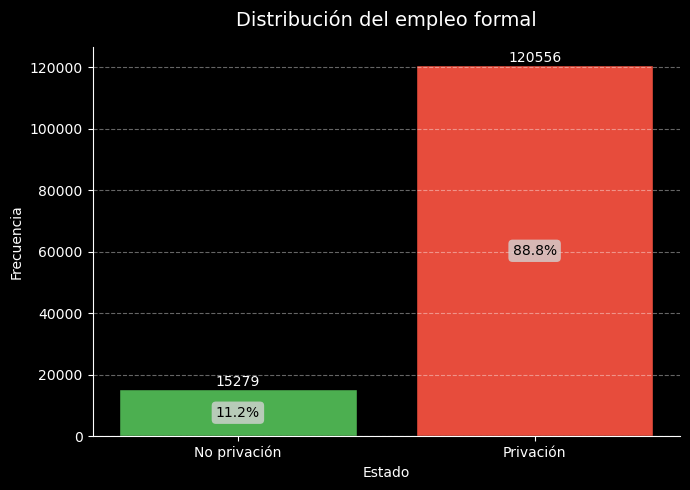

In [46]:
plot_privacion(df, "empleo_formal", "Distribución del empleo formal")

- Nivel de Privación Crítico: Esta es una de lass variables con el desempeño más alarmante de todo el estudio, con un 88.8% de los hogares (120,556 casos) en situación de privación.
- Estado de No Privación: Solo el 11.2% de los hogares cuenta con al menos un miembro ocupado que cotiza a pensiones.

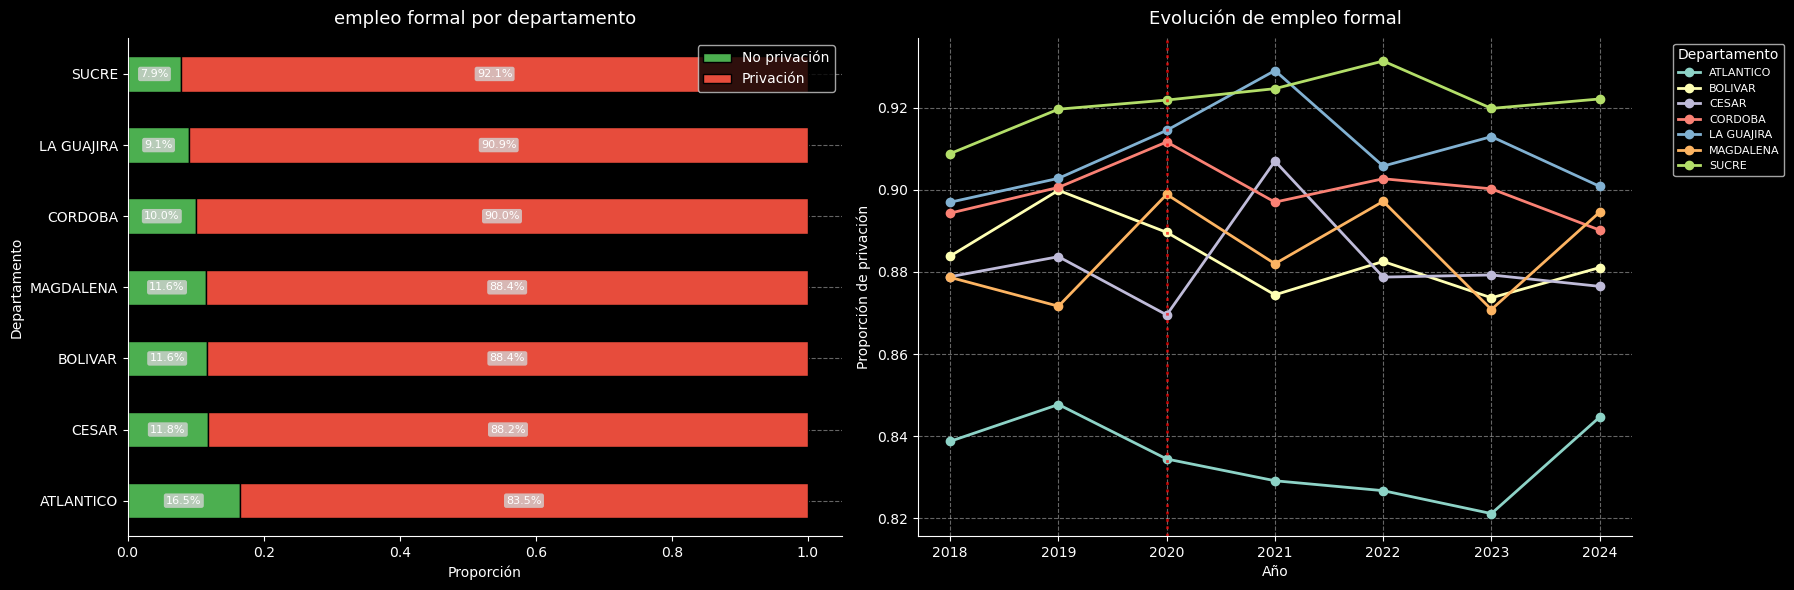

In [47]:
plot_evolucion_y_departamento(df, "empleo_formal", "empleo formal")

- Pobreza Estructural: Esta variable es la mayor barrera para el bienestar en la región. Sucre presenta la situación más crítica con un 92.1% de privación, mientras que el Atlántico, a pesar de ser el mejor posicionado, mantiene una tasa muy alta del 83.5%.

- Contraste de Formalidad: Existe una brecha mínima entre departamentos; todos superan el 83% de privación, lo que indica que la informalidad es una característica homogénea y estructural de la economía en el Caribe colombiano.

- Efecto Pandemia (2020): A diferencia de los indicadores de salud, el empleo formal sufrió un deterioro o estancamiento durante 2020. En departamentos como Córdoba y La Guajira, la privación aumentó ligeramente, reflejando la pérdida de puestos de trabajo sujetos a cotización
- Resiliencia del Atlántico: Es el único departamento que logró mantener una tendencia a la baja en la privación durante la mayor parte del periodo (2020-2023), aunque muestra un repunte preocupante hacia el cierre de 2024.

### Desempleo de larga duración

Indica una privación a nivel del hogar, tomando valor 1 (privación) si al menos un miembro de la Población Económicamente Activa (PEA) ha estado desempleado por más de 12 meses, y 0 (No privación) en caso contrario.

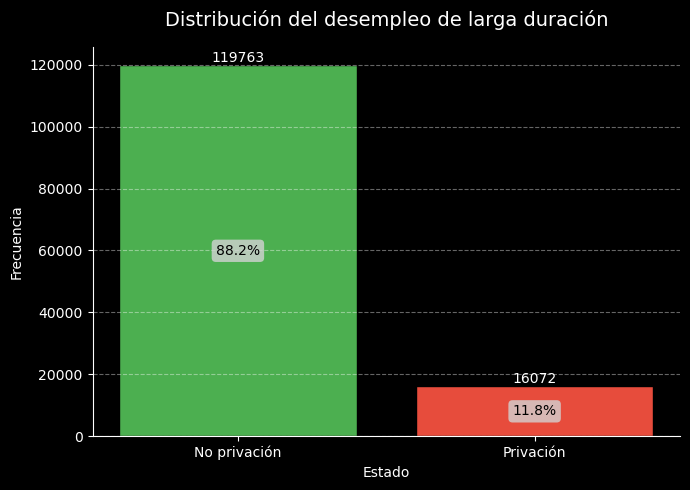

In [48]:
plot_privacion(df, "desempleo_larga_duracion", "Distribución del desempleo de larga duración")

- Bajo Nivel de Privación: Solo el 11.8% de los hogares (16,072 casos) presenta privación por desempleo de larga duración.

- Estado Predominante: El 88.2% de la muestra (119,763 hogares) se encuentra en situación de No privación, lo que indica que en la mayoría de los hogares no hay miembros de la PEA que hayan estado desempleados por más de 12 meses.

- La Paradoja Laboral: Al comparar esta gráfica con la del empleo formal (88.8% de privación), se observa un fenómeno interesante: la gente en la región Caribe no está desempleada por mucho tiempo, pero el trabajo que consiguen es mayoritariamente informal.

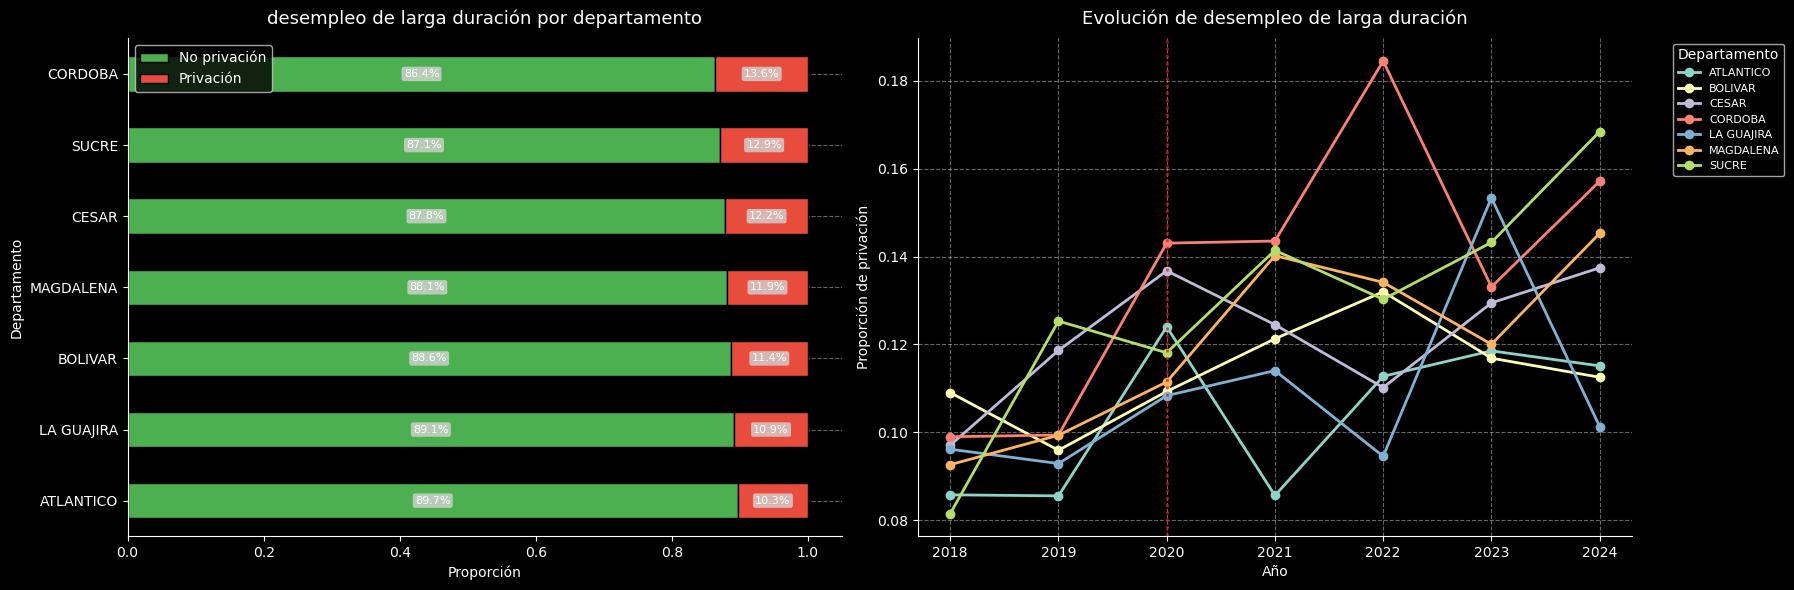

In [49]:
plot_evolucion_y_departamento(df, "desempleo_larga_duracion", "desempleo de larga duración")

- Distribución por Departamento: Córdoba registra la mayor proporción de privación con un 13.6%, seguido de Sucre (12.9%) y Cesar (12.2%). El Atlántico presenta el mejor desempeño en este indicador, con la menor tasa de privación (10.3%).
- Aunque la mayoría de los hogares no presenta esta privación (88.2% a nivel global), la evolución muestra que los mercados laborales de departamentos como Córdoba y Sucre han tenido mayores dificultades para reabsorber a la población desempleada de forma ágil tras la crisis de 2020.
- Durante el año de la emergencia sanitaria, casi todos los departamentos experimentaron un repunte en el desempleo de larga duración. Destaca el caso de Córdoba, que inició una tendencia ascendente muy pronunciada a partir de ese año.

# La historia detrás de los datos

## La pobreza es multidimensional y estructural, no solo económica

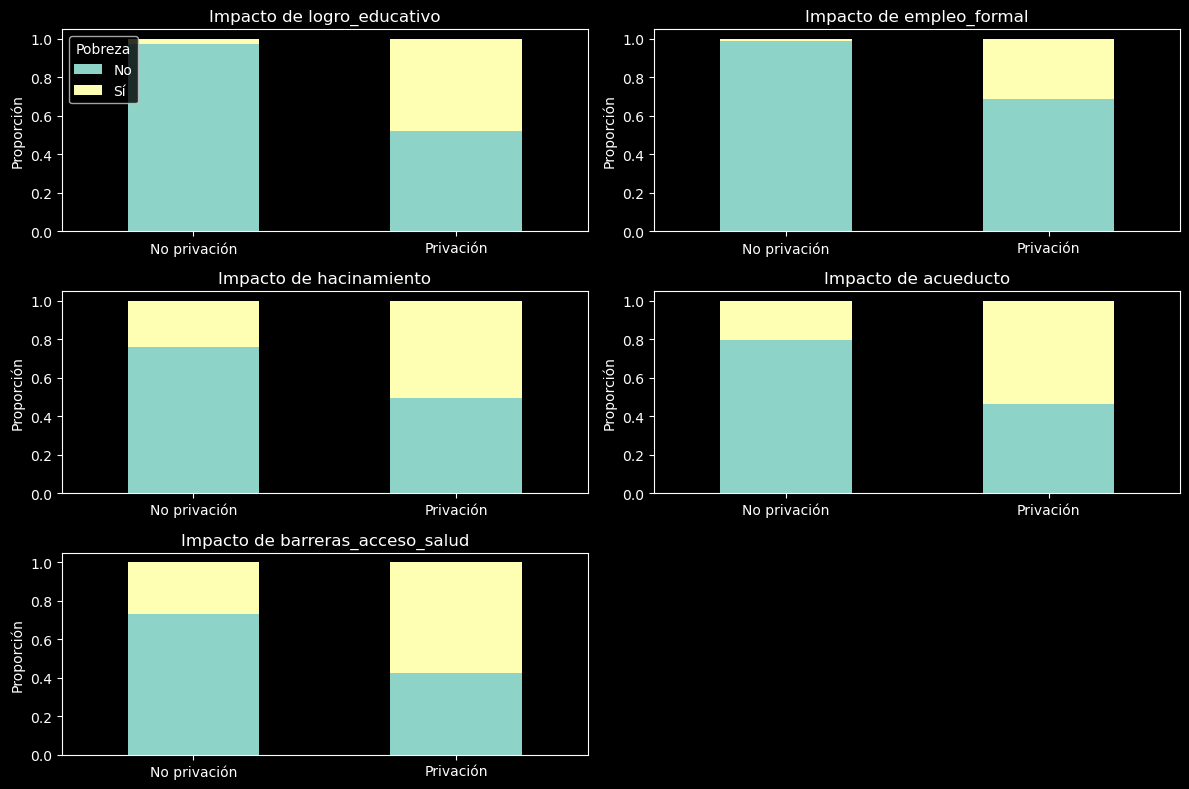

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

variables = [
    "logro_educativo",
    "empleo_formal",
    "hacinamiento",
    "acueducto",
    "barreras_acceso_salud"
]

# Definimos el número de filas y columnas para los subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 8))
axes = axes.flatten()  # Convertimos la matriz de ejes en una lista plana para iterar fácil

for i, var in enumerate(variables):
    # Crear tabla cruzada
    tabla = pd.crosstab(df[var], df["pobre"], normalize="index")
    
    # Graficar en el eje correspondiente (axes[i])
    tabla.plot(
        kind="bar",
        stacked=True,
        ax=axes[i], # Indicamos en qué cuadrante graficar
        legend=False # Quitamos la leyenda individual para personalizarla
    )
    
    # Personalización de cada subplot
    axes[i].set_title(f"Impacto de {var}", fontsize=12)
    axes[i].set_ylabel("Proporción")
    axes[i].set_xlabel("")
    axes[i].set_xticklabels(["No privación", "Privación"], rotation=0)
    
    # Añadir la leyenda solo en el primer gráfico o uno general
    if i == 0:
        axes[i].legend(["No", "Sí"], title="Pobreza", loc="upper left")

# Eliminamos el último subplot que queda vacío (el sexto)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

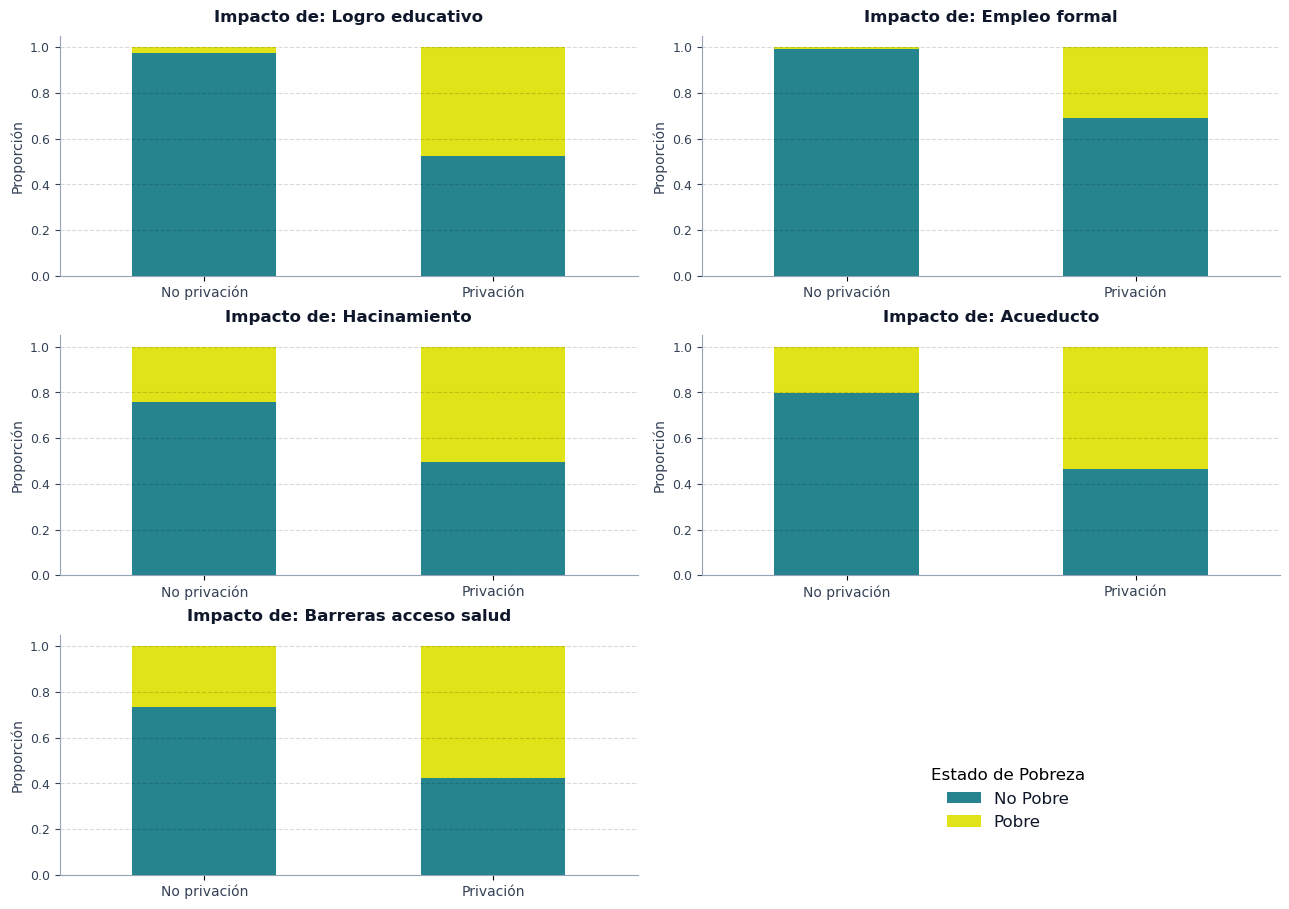

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

variables = [
    "logro_educativo",
    "empleo_formal",
    "hacinamiento",
    "acueducto",
    "barreras_acceso_salud"
]

# --- CONFIGURACIÓN DE ESTILO CLARO (FONDO BLANCO) ---
plt.style.use('default')  # Volvemos al estilo estándar limpio

# Definimos el número de filas y columnas para los subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 10))
axes = axes.flatten()  # Convertimos la matriz de ejes en una lista plana

# Forzamos que el fondo de la figura sea completamente blanco
fig.patch.set_facecolor('#ffffff')

# --- CONFIGURACIÓN DINÁMICA DE LA PALETA VIRIDIS ---
# Muestreamos la paleta nativa sobre fondo claro:
# 0.45 da un tono verde esmeralda y 0.95 da el amarillo puro de la escala Viridis
colores_viridis = [plt.cm.viridis(0.45), plt.cm.viridis(0.95)]

for i, var in enumerate(variables):
    # Crear tabla cruzada
    tabla = pd.crosstab(df[var], df["pobre"], normalize="index")
    
    # Graficar en el eje correspondiente (axes[i])
    tabla.plot(
        kind="bar",
        stacked=True,
        ax=axes[i],
        color=colores_viridis,  # Aplicamos la paleta viridis
        width=0.5,
        legend=False,
        edgecolor='none'
    )
    
    # Forzamos el fondo de cada cuadrante en blanco
    axes[i].set_facecolor('#ffffff')
    
    # Reemplazar guiones bajos por espacios para títulos más limpios
    titulo_limpio = var.replace("_", " ").capitalize()
    axes[i].set_title(f"Impacto de: {titulo_limpio}", fontsize=12, color="#0f172a", weight="bold", pad=10)
    
    # Configuración de etiquetas en tonos oscuros (gris pizarra/negro) para contraste
    axes[i].set_ylabel("Proporción", fontsize=10, color="#334155")
    axes[i].set_xlabel("")
    axes[i].set_xticklabels(["No privación", "Privación"], rotation=0, fontsize=10, color="#334155")
    axes[i].tick_params(axis='y', colors='#334155', labelsize=9)
    
    # Grid horizontal sutil adaptado a fondo claro
    axes[i].grid(axis="y", linestyle="--", alpha=0.15, color="#000000")
    
    # Ocultar los bordes superiores y derechos, y suavizar los ejes activos
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_color('#94a3b8')
    axes[i].spines['bottom'].set_color('#94a3b8')

# Crear una leyenda global única adaptada al fondo claro
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ["No Pobre", "Pobre"], loc="lower right", bbox_to_anchor=(0.85, 0.15), 
           frameon=False, fontsize=12, labelcolor="#0f172a", title="Estado de Pobreza", title_fontsize=12)

# Eliminamos el último subplot que queda vacío (el sexto)
fig.delaxes(axes[5])

plt.tight_layout()
plt.subplots_adjust(bottom=0.12) # Espacio para que no choque con la leyenda global
plt.show()

## ¿La pobreza se hereda?

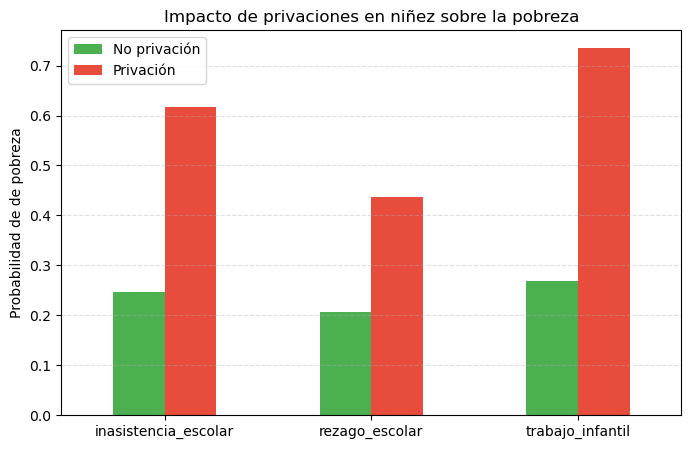

In [52]:
import matplotlib.pyplot as plt
vars_ninez = [
    "inasistencia_escolar",
    "rezago_escolar",
    "trabajo_infantil"
]
impacto = []

for var in vars_ninez:
    tabla = pd.crosstab(df[var], df["pobre"], normalize="index")
    
    # Probabilidad de ser pobre (columna 1)
    impacto.append([
        tabla.loc[0,1],  # sin privación
        tabla.loc[1,1]   # con privación
    ])

impacto = pd.DataFrame(
    impacto,
    columns=["No privación", "Privación"],
    index=vars_ninez
)

impacto.plot(kind="bar", figsize=(8,5), color=["#4CAF50", "#E74C3C"])

plt.ylabel("Probabilidad de de pobreza")
plt.title("Impacto de privaciones en niñez sobre la pobreza")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

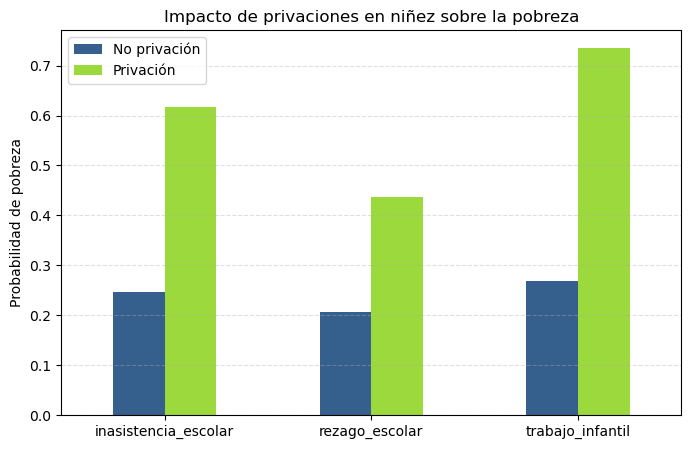

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

vars_ninez = [
    "inasistencia_escolar",
    "rezago_escolar",
    "trabajo_infantil"
]
impacto = []

for var in vars_ninez:
    tabla = pd.crosstab(df[var], df["pobre"], normalize="index")
    
    # Probabilidad de ser pobre (columna 1)
    impacto.append([
        tabla.loc[0,1],  # sin privación
        tabla.loc[1,1]   # con privación
    ])

impacto = pd.DataFrame(
    impacto,
    columns=["No privación", "Privación"],
    index=vars_ninez
)

# --- CORRECCIÓN DE PALETA VIRIDIS ---
# Extraemos dos colores equidistantes de la paleta Viridis original
# 0.25 extrae un tono azul/azul-oscuro y 0.85 extrae el amarillo/verde brillante
colores_viridis = [plt.cm.viridis(0.3), plt.cm.viridis(0.85)]

# Aplicamos los colores en el parámetro color
impacto.plot(kind="bar", figsize=(8,5), color=colores_viridis)
# ------------------------------------

plt.ylabel("Probabilidad de pobreza")  # Corregido el doble "de"
plt.title("Impacto de privaciones en niñez sobre la pobreza")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

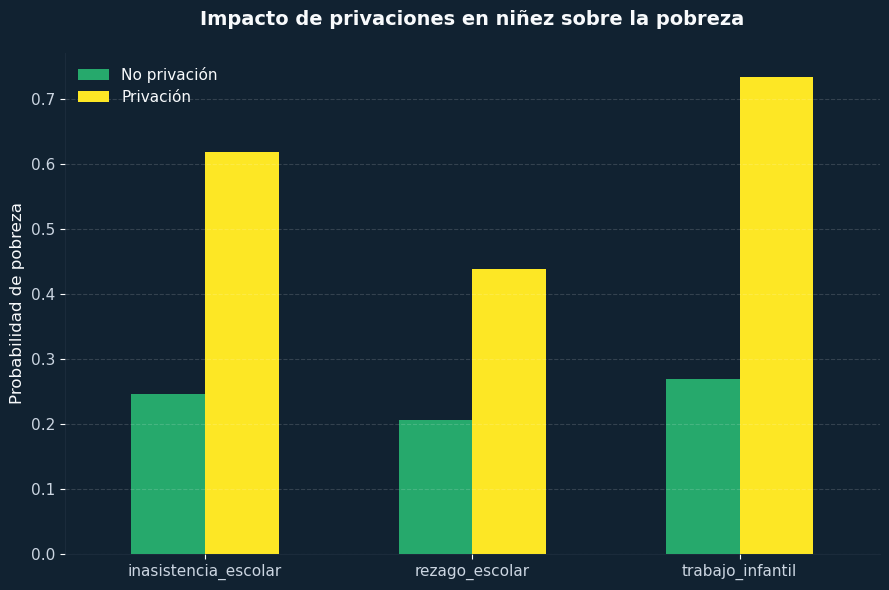

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

vars_ninez = [
    "inasistencia_escolar",
    "rezago_escolar",
    "trabajo_infantil"
]
impacto = []

for var in vars_ninez:
    tabla = pd.crosstab(df[var], df["pobre"], normalize="index")
    
    # Probabilidad de ser pobre (columna 1)
    impacto.append([
        tabla.loc[0,1],  # sin privación
        tabla.loc[1,1]   # con privación
    ])

impacto = pd.DataFrame(
    impacto,
    columns=["No privación", "Privación"],
    index=vars_ninez
)

# --- CONFIGURACIÓN DE PALETA INTEGRADA CON TU DISEÑO DE GAMMA ---
# Forzamos estilo oscuro para emparejar con el fondo azul noche de las diapositivas
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(9, 6))

# Color de fondo exacto del contenedor de tus capturas (#0f212e / #112231 aprox)
fig.patch.set_facecolor('#112231')
ax.set_facecolor('#112231')

# Colores extraídos de la onda Viridis de tus diapositivas:
# #26a96c -> Verde Esmeralda (No privación)
# #fde725 -> Amarillo Viridis Brillante (Privación / Alerta)
colores_gamma_viridis = ["#26a96c", "#fde725"]

# Graficar barras
impacto.plot(kind="bar", color=colores_gamma_viridis, ax=ax, width=0.55, edgecolor='none')
# ----------------------------------------------------------------

# Estilización de textos y ejes
plt.ylabel("Probabilidad de pobreza", fontsize=12, color="#f8fafc", fontname="sans-serif")
plt.title("Impacto de privaciones en niñez sobre la pobreza", fontsize=14, color="#f8fafc", pad=20, fontname="sans-serif", weight="bold")
plt.xticks(rotation=0, fontsize=11, color="#cbd5e1")
plt.yticks(fontsize=11, color="#cbd5e1")

# Leyenda limpia alineada con las etiquetas de Gamma
plt.legend(frameon=False, fontsize=11, loc="upper left", labelcolor="#f8fafc")

# Grid sutil horizontal
plt.grid(axis="y", linestyle="--", alpha=0.15, color="#ffffff")

# Ocultar los bordes (spines) innecesarios para un look plano y moderno como el de Gamma
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#334155')
ax.spines['bottom'].set_color('#334155')
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)

plt.tight_layout()
plt.show()

- El detonante más agresivo: Trabajo Infantil
De todas las privaciones analizadas en la niñez, el trabajo infantil es la que tiene el impacto más devastador la probabilidad de pobreza para un hogar. Un niño que se ve obligado a trabajar, su hogar tiene una probabilidad superior al 70% (0.7) de ser pobre en su vida adulta, frente a menos del 30% de quienes no sufren esta privación.

- El que un niño no asista a la escuela casi triplica el riesgo de pobreza para un hogar. Mientras que un niño que asiste, el hogar toma una probabilidad de pobreza cercana al 0.25, para aquel que deja las aulas la probabilidad se dispara por encima del 0.6. Como vimos antes, esta inasistencia está fuertemente ligada a si los padres también tuvieron privaciones educativas.

- Incluso si el niño asiste a la escuela, si lo hace con rezago (no estar en el grado correspondiente a su edad), la probabilidad de que el hogar sea pobre aumenta significativamente a más del 40%. Esto sugiere que no basta con "estar" en el sistema, sino que la calidad y la permanencia efectiva son cruciales para romper el ciclo.

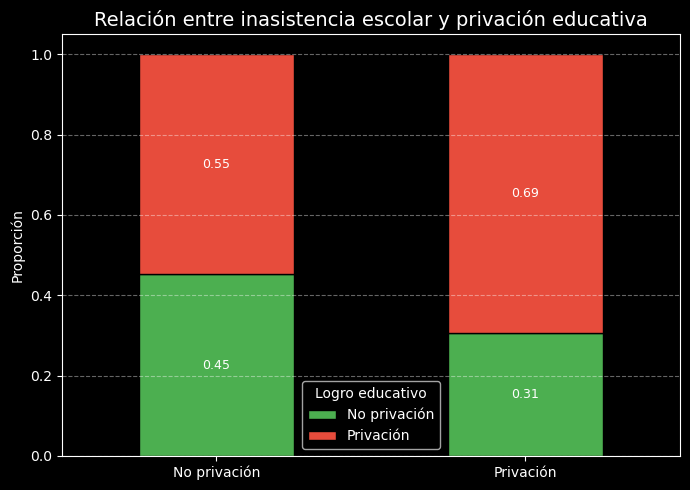

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

tabla = pd.crosstab(
    df["inasistencia_escolar"],
    df["logro_educativo"],
    normalize="index"
)

# Etiquetas claras
tabla.index = ["No privación", "Privación"]
tabla.columns = ["No privación", "Privación"]

# Colores: verde = no privación, rojo = privación
colors = ["#4CAF50", "#E74C3C"]

ax = tabla.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5),
    color=colors,
    edgecolor="black"
)

plt.title("Relación entre inasistencia escolar y privación educativa", fontsize=14)
plt.ylabel("Proporción")
plt.xlabel("")
plt.xticks(rotation=0)

# Grid suave
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Etiquetas dentro de las barras (más limpio)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0.05:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + height/2,
                f"{height:.2f}",
                ha="center",
                va="center",
                fontsize=9
            )

plt.legend(title="Logro educativo")
plt.tight_layout()
plt.show()

- Aumento de la Probabilidad: En hogares donde los adultos tienen privación educativa, la probabilidad de que los menores también presenten inasistencia escolar sube al 69% (0.69).

- El Efecto Protector de la Educación: Por el contrario, en hogares donde no hay privación educativa (padres con mayor escolaridad), la probabilidad de inasistencia escolar de los hijos cae al 55% (0.55)

## La educación es el mecanismo de escape

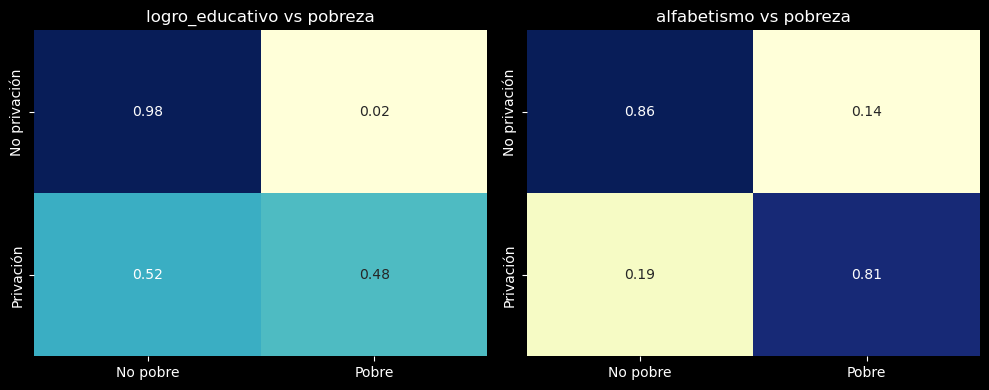

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

vars_edu = ["logro_educativo", "alfabetismo"]
n = len(vars_edu)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows))

axes = axes.flatten()  # para iterar fácil

for i, var in enumerate(vars_edu):
    tabla = pd.crosstab(df[var], df["pobre"], normalize="index")
    
    # Etiquetas más interpretables
    tabla.index = ["No privación", "Privación"]
    tabla.columns = ["No pobre", "Pobre"]
    
    sns.heatmap(
        tabla,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        cbar=False,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{var} vs pobreza")
    axes[i].set_ylabel("")
    axes[i].set_xlabel("")

# Eliminar subplots vacíos si hay número impar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

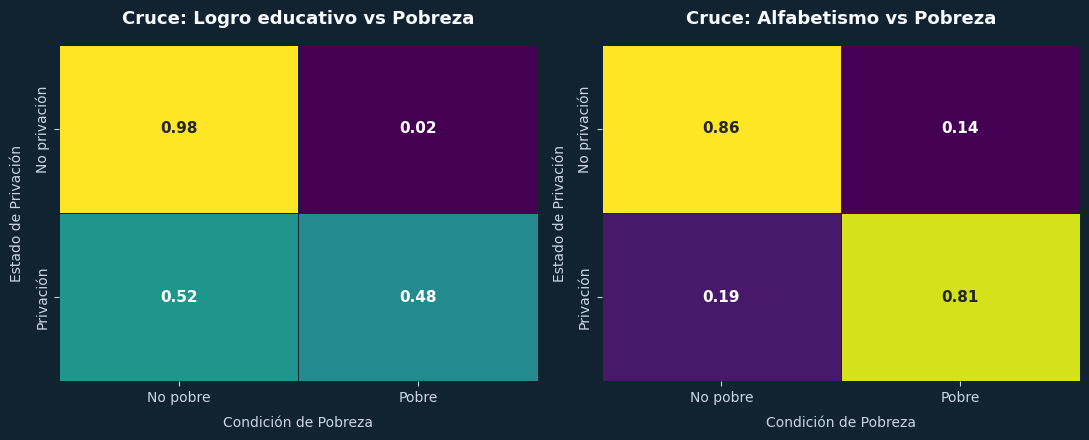

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import math

vars_edu = ["logro_educativo", "alfabetismo"]
n = len(vars_edu)
cols = 2
rows = math.ceil(n / cols)

# --- CONFIGURACIÓN DE ESTILO OSCURO DE GAMMA ---
plt.style.use('dark_background')

fig, axes = plt.subplots(rows, cols, figsize=(11, 4.5 * rows))
fig.patch.set_facecolor('#112231')  # Fondo exacto de tus diapositivas Gamma

# Asegurar que axes sea un array plano incluso si rows=1
if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, var in enumerate(vars_edu):
    tabla = pd.crosstab(df[var], df["pobre"], normalize="index")
    
    # Etiquetas más interpretables
    tabla.index = ["No privación", "Privación"]
    tabla.columns = ["No pobre", "Pobre"]
    
    # Graficar Heatmap con la paleta Viridis real de tus gráficos
    sns.heatmap(
        tabla,
        annot=True,
        fmt=".2f",
        cmap="viridis",  # Sincronizado con la onda de color de Gamma
        cbar=False,
        ax=axes[i],
        annot_kws={"size": 11, "weight": "bold"}, # Textos internos estilizados
        linewidths=0.5,
        linecolor="#112231" # Separador sutil con el mismo color de fondo
    )
    
    # Formatear el título de la variable
    titulo_var = var.replace("_", " ").capitalize()
    axes[i].set_title(f"Cruce: {titulo_var} vs Pobreza", fontsize=13, color="#f8fafc", weight="bold", pad=15)
    
    # Estilizar las etiquetas de los ejes
    axes[i].tick_params(axis='x', colors='#cbd5e1', labelsize=10)
    axes[i].tick_params(axis='y', colors='#cbd5e1', labelsize=10)
    axes[i].set_ylabel("Estado de Privación", fontsize=10, color="#cbd5e1", labelpad=8)
    axes[i].set_xlabel("Condición de Pobreza", fontsize=10, color="#cbd5e1", labelpad=8)

# Eliminar subplots vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

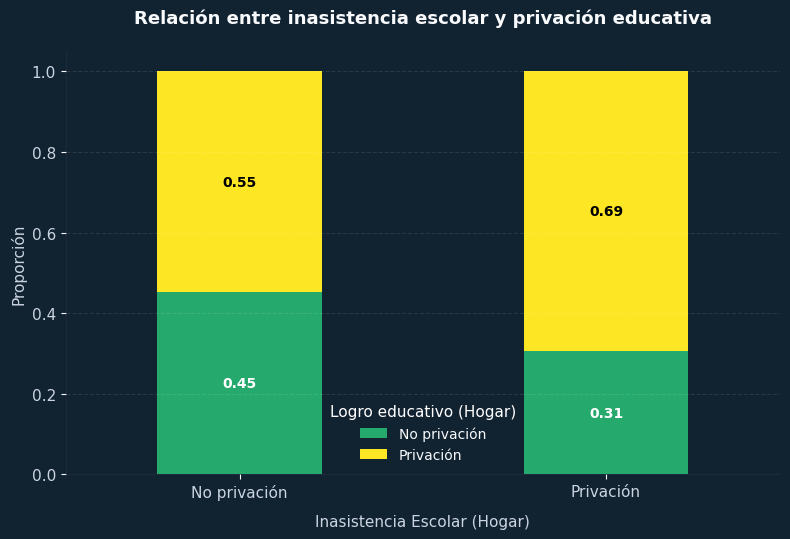

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

tabla = pd.crosstab(
    df["inasistencia_escolar"],
    df["logro_educativo"],
    normalize="index"
)

# Etiquetas claras
tabla.index = ["No privación", "Privación"]
tabla.columns = ["No privación", "Privación"]

# --- CONFIGURACIÓN DE ESTILO OSCURO DE GAMMA ---
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(8, 5.5))

# Color de fondo exacto del contenedor de tus diapositivas
fig.patch.set_facecolor('#112231')
ax.set_facecolor('#112231')

# Colores extraídos de la onda Viridis de tus diapositivas:
# #26a96c -> Verde Esmeralda (No privación en logro educativo)
# #fde725 -> Amarillo Viridis Brillante (Privación en logro educativo / Alerta)
colores_gamma_viridis = ["#26a96c", "#fde725"]

# Graficar barras apiladas (quitamos el borde negro para un look plano/flat moderno)
tabla.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colores_gamma_viridis,
    width=0.45,
    edgecolor="none"
)
# ------------------------------------------------

plt.title("Relación entre inasistencia escolar y privación educativa", fontsize=13, color="#f8fafc", weight="bold", pad=20)
plt.ylabel("Proporción", fontsize=11, color="#cbd5e1")
plt.xlabel("Inasistencia Escolar (Hogar)", fontsize=11, color="#cbd5e1", labelpad=10)
plt.xticks(rotation=0, fontsize=11, color="#cbd5e1")
plt.yticks(fontsize=11, color="#cbd5e1")

# Grid horizontal sutil
plt.grid(axis="y", linestyle="--", alpha=0.1, color="#ffffff")

# Etiquetas dentro de las barras con colores contrastantes para fondo oscuro
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0.05:
            # Determinamos el color del texto según la barra para máxima legibilidad:
            # Texto negro sobre el amarillo brillante, texto blanco sobre el verde esmeralda
            color_texto = "#000000" if bar.get_facecolor() == ax.patches[2].get_facecolor() or bar.get_facecolor() == ax.patches[3].get_facecolor() else "#ffffff"
            
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + height/2,
                f"{height:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color=color_texto,
                weight="bold"
            )

# Leyenda limpia alineada con el estilo de Gamma
plt.legend(title="Logro educativo (Hogar)", frameon=False, fontsize=10, title_fontsize=11, labelcolor="#f8fafc")

# Ocultar los bordes (spines) innecesarios
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#334155')
ax.spines['bottom'].set_color('#334155')
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)

plt.tight_layout()
plt.show()

- El impacto de saber leer y escribir es radical para cambiar el destino de una persona.

    - Un individuo con privación en alfabetismo tiene una proporción del 81% de con ser pobre. 

    - Al eliminar esa privación, la proporción de ser pobre se desploma al 14%. El alfabetismo es, literalmente, el umbral entre la exclusión y la oportunidad.

- El Logro Educativo como Escudo contra la Pobreza

    - El alcanzar los niveles educativos esperados para la edad adulta actúa como un escudo de protección casi total.

    - Hogares con Logro: Aquellos que no presentan privación en logro educativo tienen una proporción del 98% de no ser pobres (solo un 2% de margen de pobreza).

    - Hogares sin Logro: Cuando los adultos no alcanzan los niveles mínimos de educación, el hogar queda en un "volado" estadístico: casi el 50% de proporción (0.48) de caer en la pobreza multidimensional.

## Análisis de dimensiones y departamentos

Podemos escalar a nivel regional, observando las privaciones anteriores, podemos comparar la proporción que tienen con base a los departamentos de la región.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

grupos = {
    "Educación": [
        "logro_educativo",
        "alfabetismo"
    ],
    "Niñez y juventud": [
        "rezago_escolar",
        "inasistencia_escolar",
        "atencion_integral",   # servicios de cuidado a la primera infancia
        "trabajo_infantil"
    ],
    "Salud": [
        "aseguramiento_salud",
        "barreras_acceso_salud"  # acceso a salud dada una necesidad
    ],
    "Trabajo": [
        "empleo_formal",
        "desempleo_larga_duracion"
    ],
    "Vivienda": [
        "acueducto",        # fuente de agua mejorada
        "alcantarillado",   # eliminación de excretas
        "pisos",
        "paredes",
        "hacinamiento"
    ]
}

# ─────────────────────────────────────────
# 1. FILTRAR REGIÓN CARIBE
# ─────────────────────────────────────────
departamentos_region = [
    "ATLANTICO",
    "BOLIVAR",
    "CESAR",
    "CORDOBA",
    "SUCRE",
    "MAGDALENA",
    "LA GUAJIRA"
]

df_region = df[df["departamento_nombre"].isin(departamentos_region)]

# ─────────────────────────────────────────
# 2. PROMEDIO PONDERADO POR DEPARTAMENTO
# ─────────────────────────────────────────
resultados = {}

for dep, df_dep in df_region.groupby("departamento_nombre"):
    
    resultados[dep] = {}
    
    for grupo, variables in grupos.items():
        
        valores = []
        
        for var in variables:
            val = np.average(df_dep[var], weights=df_dep["fexp"])
            valores.append(val)
        
        resultados[dep][grupo] = np.mean(valores) * 100

# ─────────────────────────────────────────
# 3. DATAFRAME
# ─────────────────────────────────────────
df_comp = pd.DataFrame(resultados).T

# ─────────────────────────────────────────
# 4. NORMALIZAR (PROPORCIONES)
# ─────────────────────────────────────────
df_prop = df_comp.div(df_comp.sum(axis=1), axis=0)

# ─────────────────────────────────────────
# 5. BARRAS APILADAS
# ─────────────────────────────────────────
ax = df_prop.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)

plt.title("Composición de privaciones por departamento (Caribe)")
plt.xlabel("Departamento")
plt.ylabel("Proporción")

plt.xticks(rotation=45)

plt.legend(title="Dimensión", bbox_to_anchor=(1.02, 1), loc="upper left")

# ─────────────────────────────────────────
# 6. ETIQUETAS (OPCIONAL)
# ─────────────────────────────────────────
for container in ax.containers:
    labels = [f"{v:.1%}" for v in container.datavalues]
    
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=7,
        bbox=dict(
            facecolor="lightgray",
            edgecolor="none",
            boxstyle="round,pad=0.2",
            alpha=0.7
        )
    )

plt.tight_layout()
plt.show()

Las dimensiones que más tienen prevalencia son constantes en todos los departamentos: Trabajo y educación. Aproximadamente casi la mitad de todos los hogares en la región Caribe tienen privaciones relacionadas al trabajo, y casi 2 de cada 5 hogares tienen privación con relación a educación.

Asimismo, podemos también observarlo en escala departamental, en este caso, el departamento del Atlantico.

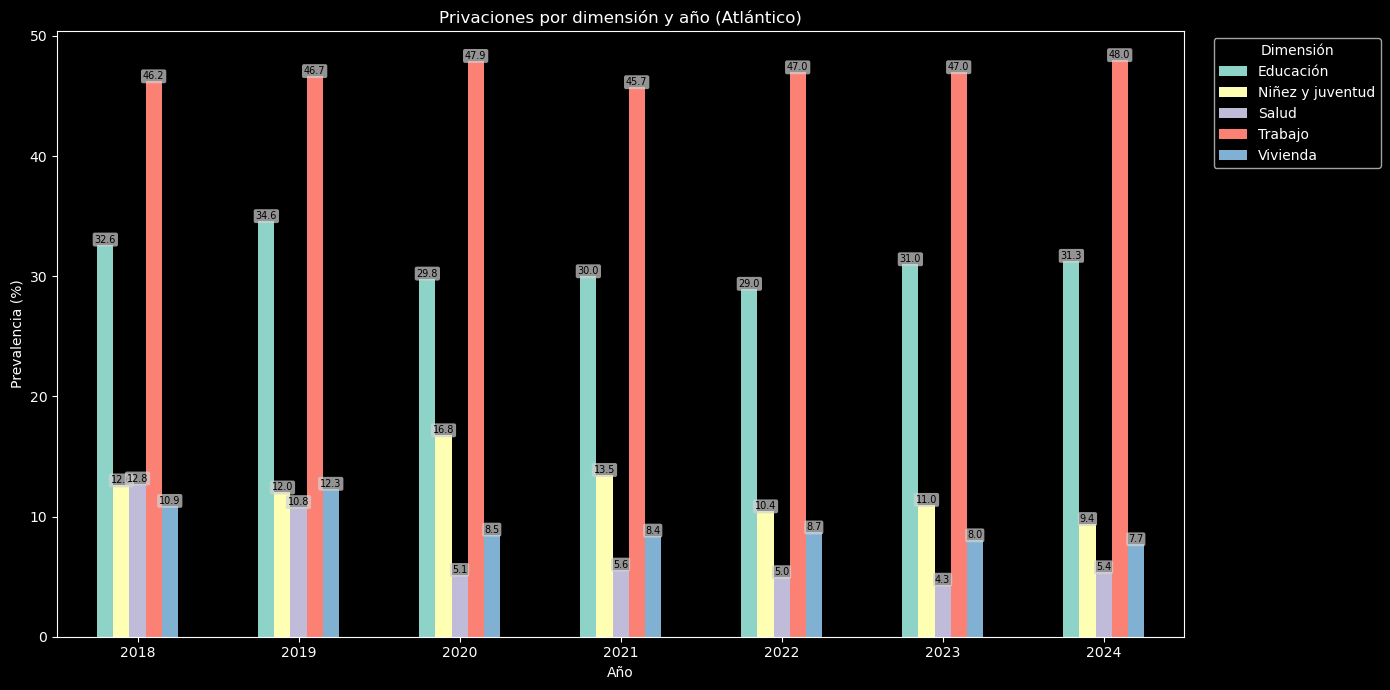

In [ ]:
import matplotlib.pyplot as plt

df_atlantico = df[df["departamento_nombre"] == "ATLANTICO"]

resultados_atlantico = {}

for grupo, variables in grupos.items():
    resultados_atlantico[grupo] = (
        df_atlantico
        .groupby("año")[variables]
        .mean()
        .mean(axis=1) * 100
    )
df_dim_atl = pd.DataFrame(resultados_atlantico)

df_dim_atl = pd.DataFrame(resultados_atlantico)

fig, ax = plt.subplots(figsize=(14,7))

df_dim_atl.plot(kind="bar", ax=ax)

plt.title("Privaciones por dimensión y año (Atlántico)")
plt.xlabel("Año")
plt.ylabel("Prevalencia (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    labels = [f"{v:.1f}" if v > 0.5 else "" for v in container.datavalues]
    
    ax.bar_label(
        container,
        labels=labels,
        label_type="edge",
        fontsize=7,
        color="black",
        bbox=dict(
            facecolor="lightgray",
            edgecolor="none",
            boxstyle="round,pad=0.2",
            alpha=0.7
        )
    )

plt.legend(title="Dimensión", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

Las conclusiones, como se pudieron observar en la grafica departamental, reflejan un comportamiento similar.